<div style="
    background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);
    padding: 30px;
    border-radius: 10px;
    box-shadow: 0 4px 15px rgba(0,0,0,0.1);
    text-align: center;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    margin-bottom: 20px;
">
    <h1 style="color: #ffffff; margin: 0 0 15px 0; font-size: 32px; font-weight: 700; letter-spacing: 1px;">
        Early Stopping com Validação Dinâmica em Blocos
    </h1>
    <p style="color: #e0e0e0; margin: 0; font-size: 16px; font-weight: 300; letter-spacing: 0.5px;">
        T3 - Machine Learning
    </p>
    <hr style="border: 0; height: 1px; background: rgba(255,255,255,0.3); margin: 0 auto 15px auto; width: 40%;">
    <p style="color: #b0c4de; margin: 0; font-size: 13px; font-style: italic;">
        Erich Johann Costa de Carvalho • Maria Vitória da Silva Vieira • Matheus de Souza Figueiredo
    </p>
</div>

# Contexto

Explicar: 
- Validação dinâmica
- Problemas validação dinâmica
- Early Stopping
- Problemas junção Val Dinâmica + ES
- Estratégias de early stopping
- Tema: validação em blocos 

# Carregando datasets que serão usados


### Student

In [ ]:
import os
import urllib.request
import zipfile
import pandas as pd

arquivo = "student-mat.csv"
url_zip = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

if not os.path.exists(arquivo):
    temp_zip = "temp_student.zip"

    # Baixa o arquivo zip
    urllib.request.urlretrieve(url_zip, temp_zip)

    # Extrai apenas o arquivo necessário
    with zipfile.ZipFile(temp_zip, 'r') as zip_ref:
        zip_ref.extract(arquivo, path=".")

    os.remove(temp_zip)
    print("Baixado student-mat.csv via student.zip da UCI.")

else:
    print("student-mat.csv já existe localmente.")

student = pd.read_csv(arquivo, sep=";")

student-mat.csv já existe localmente.


### Titanic

In [2]:
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

dataset = pd.read_csv(url_titanic)

# Renomear coluna alvo para seguir o mesmo padrão do wine (Survived -> Class)
dataset = dataset.rename(columns={"Survived": "Class"})

# Converter para o tipo "category" (equivalente ao factor do R)
dataset["Class"] = dataset["Class"].astype("category")

print("Dataset Titanic carregado do link e salvo como 'dataset' com target = 'Class'.")

Dataset Titanic carregado do link e salvo como 'dataset' com target = 'Class'.


# Pré Processamento de dados

### Student
- One hot encoding de variáveis categóricas
- Separação treino/teste 80/20
- Normalização Min-max

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

dataset_student = student.copy()
seed_utilizada = 42

target_student = "G3"

X_student = dataset_student.drop(columns=[target_student])
y_student = dataset_student[target_student]

#One-hot encoding em todas as variáveis categóricas
X_student_encoded = pd.get_dummies(X_student, drop_first=False, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X_student_encoded, y_student, test_size=0.2, random_state=seed_utilizada
)

# Scaling baseado APENAS no treino (MinMax)
scaler_student = MinMaxScaler()

train_scaled_student = scaler_student.fit_transform(X_train)
test_scaled_student = scaler_student.transform(X_test)

student_cols = X_train.columns.tolist()
df_train_mlp_reg = pd.DataFrame(train_scaled_student, columns=student_cols)
df_test_mlp_reg = pd.DataFrame(test_scaled_student, columns=student_cols)

df_train_mlp_reg[target_student] = y_train.values
df_test_mlp_reg[target_student] = y_test.values

input_dim_student = len(student_cols)

print("Pré-processamento do Student Performance concluído.")
print(f"Formato do Treino: {train_scaled_student.shape} | Teste: {test_scaled_student.shape}")

Pré-processamento do Student Performance concluído.
Formato do Treino: (316, 58) | Teste: (79, 58)


### Titanic
- Seleção de colunas numéricas válidas
- Omissão de valores faltantes
- Separação treino/teste 80/20
- Normalização Min-max

In [4]:
target_titanic = "Class"
seed_utilizada = 42
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

# Cria uma cópia focando apenas nas colunas desejadas
dataset_titanic = dataset[numeric_features + [target_titanic]].copy()

# Remove linhas com valores ausentes (NaN) nas colunas selecionadas
dataset_titanic = dataset_titanic.dropna()

X_titanic = dataset_titanic[numeric_features]
y_titanic = dataset_titanic[target_titanic]
slevels_titanic = list(y_titanic.unique())


X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=seed_utilizada
)

# Scaling usando apenas treino
scaler_titanic = MinMaxScaler()

train_scaled_titanic = scaler_titanic.fit_transform(X_train_t)
test_scaled_titanic = scaler_titanic.transform(X_test_t)

df_train_mlp_cla = pd.DataFrame(train_scaled_titanic, columns=numeric_features)

# Inserir coluna alvo 'Class' usando .values para alinhar os índices
df_train_mlp_cla["Class"] = y_train_t.values 

df_test_mlp_cla = pd.DataFrame(test_scaled_titanic, columns=numeric_features)

input_dim_titanic = len(numeric_features)
num_class = df_train_mlp_cla["Class"].nunique() # Retorna 2 (Sobreviveu ou Não)

print("Pré-processamento Titanic concluído.")
print(f"Formato do Treino: {train_scaled_titanic.shape} | Validação: {test_scaled_titanic.shape}")

Pré-processamento Titanic concluído.
Formato do Treino: (571, 5) | Validação: (143, 5)


# Experimento

- Set up configurações de treinamento

In [5]:
import random
import numpy as np
import torch

#Função para definição de seeds
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

#Arq da rede mlp
hidden_sizes = [64, 32]

#Blocos de validação que serão usados
Blocos = [1, 5, 10, 20, 30, 50]
experiments_results_cla = []
experiments_results_reg = []
loss_hist_cla={}
loss_hist_reg={}

seed = 42
seeds = []
seed_everything(seed)
#Geração de 30 seeds aletaórias
if not seeds:
    for i in range(30):
        s = random.randint(10000000, 99999999)
        seeds.append(s)

print("Configurações de treinamento setadas")
print(f"Seeds geradas: {seeds}")

Configurações de treinamento setadas
Seeds geradas: [95822412, 24942603, 13356886, 46913810, 42868828, 39958838, 28728463, 23756669, 83197857, 21668732, 89254563, 66629388, 14265799, 13999315, 22575562, 39345092, 41227216, 77827638, 90801586, 13561597, 85329037, 36687537, 97226012, 83140807, 66306997, 39587039, 70291817, 89089901, 47338124, 10872248]


# Classificação

### MLP Classificação

In [6]:
"""
Unified PyTorch MLP classifier used by daltoolboxdp via reticulate.
"""

from dataclasses import dataclass
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import ttest_ind
from torch.utils.data import DataLoader, TensorDataset


VALIDATION_STRATEGIES = {"static", "dynamic"}
STOPPING_RULES = {"none", "patience", "sma", "ema", "h"}


@dataclass
class _TrainingConfig:
    epochs: int = 100
    lr: float = 0.001
    val_ratio: float = 0.2
    batch_size: int = 64
    patience: int = 100
    min_delta: float = 1e-4
    sma_window: int = 5
    ema_alpha: float = 0.2
    test_window: int = 30
    p_value: float = 0.05
    weight_decay: float = 0.0
    B: int = 1


def _activation_module(name: str) -> nn.Module:
    name = str(name).lower()
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "leaky_relu":
        return nn.LeakyReLU(0.2, inplace=True)
    if name == "elu":
        return nn.ELU(inplace=True)
    if name == "gelu":
        return nn.GELU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unsupported activation: {name}")


def _normalization_module(kind: str, dim: int) -> Optional[nn.Module]:
    kind = str(kind).lower()
    if kind == "none":
        return None
    if kind == "batch":
        return nn.BatchNorm1d(int(dim))
    if kind == "layer":
        return nn.LayerNorm(int(dim))
    raise ValueError("normalization must be one of {'none', 'batch', 'layer'}")


def _apply_init(module: nn.Module, init_method: str):
    init_method = str(init_method).lower()
    if isinstance(module, nn.Linear):
        if init_method == "xavier_uniform":
            nn.init.xavier_uniform_(module.weight)
        elif init_method == "xavier_normal":
            nn.init.xavier_normal_(module.weight)
        elif init_method == "kaiming_uniform":
            nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
        elif init_method == "kaiming_normal":
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        elif init_method == "default":
            return
        else:
            raise ValueError(f"Unsupported init_method: {init_method}")
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class TorchMLPClassifierNet(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_sizes: List[int],
        num_classes: int,
        dropout: float = 0.0,
        activation: str = "relu",
        normalization: str = "none",
        init_method: str = "default",
    ):
        super().__init__()
        layers = []
        prev = int(input_dim)
        if isinstance(hidden_sizes, (int, np.integer)):
            hidden_sizes = [int(hidden_sizes)]
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, int(h)))
            norm = _normalization_module(normalization, int(h))
            if norm is not None:
                layers.append(norm)
            layers.append(_activation_module(activation))
            if float(dropout) > 0:
                layers.append(nn.Dropout(p=float(dropout)))
            prev = int(h)
        layers.append(nn.Linear(prev, int(num_classes)))
        self.net = nn.Sequential(*layers)
        self.net.apply(lambda module: _apply_init(module, init_method))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class _StopController:
    def __init__(self, rule: str, min_delta: float, patience: int, sma_window: int, ema_alpha: float, test_window: int, p_value: float):
        self.rule = rule
        self.min_delta = float(min_delta)
        self.patience = int(patience)
        self.sma_window = max(1, int(sma_window))
        self.ema_alpha = float(ema_alpha)
        self.test_window = max(2, int(test_window))
        self.p_value = float(p_value)
        self.best_value = float("inf")
        self.best_state = None
        self.patience_ctr = 0
        self.ema_value = None
        self.val_history: List[float] = []

    def _clone_state(self, model: nn.Module):
        return {k: v.detach().clone() for k, v in model.state_dict().items()}

    def _h_improved(self) -> bool:
        if len(self.val_history) < 2 * self.test_window:
            if len(self.val_history) == 1:
                return True
            return self.val_history[-1] < min(self.val_history[:-1])
        prev_window = self.val_history[-2 * self.test_window : -self.test_window]
        recent_window = self.val_history[-self.test_window :]
        _, p_value = ttest_ind(prev_window, recent_window, equal_var=False, alternative="greater")
        return bool(p_value < self.p_value)

    def step(self, model: nn.Module, current: float) -> bool:
        self.val_history.append(float(current))
        if self.rule == "none":
            self.best_state = self._clone_state(model)
            return False
        if self.rule == "h":
            improved = self._h_improved()
            if improved:
                self.best_state = self._clone_state(model)
                self.patience_ctr = 0
            else:
                self.patience_ctr += 1
            return self.patience_ctr >= self.patience

        if self.rule == "patience":
            monitor_value = float(current)
        elif self.rule == "sma":
            monitor_value = float(np.mean(self.val_history[-self.sma_window :]))
        elif self.rule == "ema":
            if self.ema_value is None:
                self.ema_value = current
            else:
                self.ema_value = self.ema_alpha * current + (1.0 - self.ema_alpha) * self.ema_value
            monitor_value = float(self.ema_value)
        else:
            raise ValueError(f"Unsupported stopping rule: {self.rule}")

        if (self.best_value - monitor_value) > self.min_delta:
            self.best_value = monitor_value
            self.best_state = self._clone_state(model)
            self.patience_ctr = 0
        else:
            self.patience_ctr += 1
        return self.patience_ctr >= self.patience


class TorchMLPClassifier:
    def __init__(
        self,
        input_dim: int,
        hidden_sizes: List[int],
        num_classes: int,
        dropout: float = 0.0,
        activation: str = "relu",
        normalization: str = "none",
        init_method: str = "default",
        validation_strategy: str = "static",
        stopping_rule: str = "none",
    ):
        validation_strategy = str(validation_strategy).lower()
        stopping_rule = str(stopping_rule).lower()
        if validation_strategy not in VALIDATION_STRATEGIES:
            raise ValueError(f"validation_strategy must be one of {sorted(VALIDATION_STRATEGIES)}")
        if stopping_rule not in STOPPING_RULES:
            raise ValueError(f"stopping_rule must be one of {sorted(STOPPING_RULES)}")
        self.validation_strategy = validation_strategy
        self.stopping_rule = stopping_rule
        self.network = TorchMLPClassifierNet(
            input_dim,
            hidden_sizes,
            num_classes,
            dropout=dropout,
            activation=activation,
            normalization=normalization,
            init_method=init_method,
        ).to(self._device())
        self.classes_: List = []
        self.train_loss_hist: List[float] = []
        self.val_loss_hist: List[float] = []
        self.epochs_done: int = 0

    @staticmethod
    def _device():
        return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    @staticmethod
    def _prepare_xy(df: pd.DataFrame, target_column: str, classes_: Optional[List]) -> Tuple[torch.Tensor, torch.Tensor, List]:
        X = df.drop(columns=[target_column]).to_numpy().astype(np.float32)
        y_raw = df[target_column].to_numpy()
        if classes_ is None:
            classes_ = sorted(pd.Series(y_raw).astype("category").cat.categories.tolist())
        class_to_idx = {c: i for i, c in enumerate(classes_)}
        y = np.array([class_to_idx[c] for c in y_raw], dtype=np.int64)
        return torch.from_numpy(X), torch.from_numpy(y), classes_

    @staticmethod
    def _split_indices(n_samples: int, val_ratio: float) -> Tuple[np.ndarray, np.ndarray]:
        rng = np.random.default_rng()
        idx = np.arange(n_samples)
        rng.shuffle(idx)
        n_val = max(1, int(n_samples * float(val_ratio)))
        return idx[n_val:], idx[:n_val]

    def _epoch(self, loader: DataLoader, optimizer: Optional[torch.optim.Optimizer], criterion: nn.Module) -> float:
        losses: List[float] = []
        if optimizer is None:
            self.network.eval()
            with torch.no_grad():
                for xb, yb in loader:
                    xb = xb.float().to(self._device())
                    yb = yb.long().to(self._device())
                    losses.append(float(criterion(self.network(xb), yb).item()))
        else:
            self.network.train()
            for xb, yb in loader:
                xb = xb.float().to(self._device())
                yb = yb.long().to(self._device())
                optimizer.zero_grad()
                loss = criterion(self.network(xb), yb)
                loss.backward()
                optimizer.step()
                losses.append(float(loss.item()))
        return float(np.mean(losses)) if losses else 0.0

    def fit(self, df_train: pd.DataFrame, target_column: str, config: _TrainingConfig, classes_: Optional[List] = None):

        X_all, y_all, self.classes_ = self._prepare_xy(df_train, target_column, classes_)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.network.parameters(), lr=float(config.lr), weight_decay=float(config.weight_decay))
        stopper = _StopController(self.stopping_rule, config.min_delta, config.patience, config.sma_window, config.ema_alpha, config.test_window, config.p_value)

        self.train_loss_hist = []
        self.val_loss_hist = []
        self.epochs_done = 0

        if self.validation_strategy == "static" and self.stopping_rule != "none":
            train_idx, val_idx = self._split_indices(X_all.shape[0], config.val_ratio)
            train_loader = DataLoader(TensorDataset(X_all[train_idx], y_all[train_idx]), batch_size=int(config.batch_size), shuffle=True, drop_last=False)
            val_loader = DataLoader(TensorDataset(X_all[val_idx], y_all[val_idx]), batch_size=int(config.batch_size), shuffle=False, drop_last=False)
        elif self.validation_strategy == "static":
            train_loader = DataLoader(TensorDataset(X_all, y_all), batch_size=int(config.batch_size), shuffle=True, drop_last=False)
            val_loader = None
        else:
            train_loader = None
            val_loader = None

        for epoch in range(int(config.epochs)):
            self.epochs_done += 1
            if self.validation_strategy == "dynamic" and (epoch % config.B) == 0:
                train_idx, val_idx = self._split_indices(X_all.shape[0], config.val_ratio)
                train_loader = DataLoader(TensorDataset(X_all[train_idx], y_all[train_idx]), batch_size=int(config.batch_size), shuffle=True, drop_last=False)
                val_loader = DataLoader(TensorDataset(X_all[val_idx], y_all[val_idx]), batch_size=int(config.batch_size), shuffle=False, drop_last=False)

            self.train_loss_hist.append(self._epoch(train_loader, optimizer, criterion))
            if val_loader is not None:
                val_loss = self._epoch(val_loader, None, criterion)
                self.val_loss_hist.append(val_loss)
                if stopper.step(self.network, val_loss):
                    break

        if stopper.best_state is not None:
            self.network.load_state_dict(stopper.best_state)
        return self

    def predict(self, df_test: pd.DataFrame):
        X = torch.from_numpy(df_test.to_numpy().astype(np.float32))
        self.network.eval()
        with torch.no_grad():
            logits = self.network(X.to(self._device()))
            pred_idx = torch.argmax(logits, dim=-1).cpu().numpy().tolist()
        idx_to_class = {i: c for i, c in enumerate(self.classes_)}
        return [idx_to_class[i] for i in pred_idx]

    def predict_scores(self, df_test: pd.DataFrame):
        X = torch.from_numpy(df_test.to_numpy().astype(np.float32))
        self.network.eval()
        with torch.no_grad():
            logits = self.network(X.to(self._device()))
            scores = F.softmax(logits, dim=-1).cpu().numpy()
        return scores.tolist()


def torch_cla_mlp_create(
    input_dim: int,
    hidden_sizes: List[int],
    num_classes: int,
    dropout: float = 0.0,
    activation: str = "relu",
    normalization: str = "none",
    init_method: str = "default",
    validation_strategy: str = "static",
    stopping_rule: str = "none",
):
    return TorchMLPClassifier(
        input_dim,
        hidden_sizes,
        num_classes,
        dropout=dropout,
        activation=activation,
        normalization=normalization,
        init_method=init_method,
        validation_strategy=validation_strategy,
        stopping_rule=stopping_rule,
    )


def torch_cla_mlp_fit(
    model,
    df_train: pd.DataFrame,
    target_column: str,
    epochs: int = 100,
    lr: float = 1e-3,
    validation_strategy: str = "static",
    stopping_rule: str = "none",
    batch_size: int = 64,
    val_ratio: float = 0.2,
    patience: int = 100,
    min_delta: float = 1e-4,
    sma_window: int = 5,
    ema_alpha: float = 0.2,
    test_window: int = 30,
    p_value: float = 0.05,
    weight_decay: float = 0.0,
    classes_: Optional[List] = None,
    B: int = 1
):
    model.validation_strategy = str(validation_strategy).lower()
    model.stopping_rule = str(stopping_rule).lower()
    config = _TrainingConfig(
        epochs=int(epochs),
        lr=float(lr),
        val_ratio=float(val_ratio),
        batch_size=int(batch_size),
        patience=int(patience),
        min_delta=float(min_delta),
        sma_window=int(sma_window),
        ema_alpha=float(ema_alpha),
        test_window=int(test_window),
        p_value=float(p_value),
        weight_decay=float(weight_decay),
        B=int(B)
    )
    return model.fit(df_train, target_column=target_column, config=config, classes_=classes_)


def torch_cla_mlp_predict(model, df_test: pd.DataFrame, classes_: Optional[List] = None):
    if classes_ is not None and not model.classes_:
        model.classes_ = list(classes_)
    return model.predict(df_test)


def torch_cla_mlp_predict_scores(model, df_test: pd.DataFrame, classes_: Optional[List] = None):
    if classes_ is not None and not model.classes_:
        model.classes_ = list(classes_)
    return model.predict_scores(df_test)

### Treinamento modelo estático

In [7]:
from sklearn.metrics import classification_report

for s in seeds:
    seed_everything(s)
    
    mlp_cla_es = TorchMLPClassifier(
        input_dim=input_dim_titanic,
        hidden_sizes=hidden_sizes,
        num_classes=num_class,
        dropout=0.1,
        validation_strategy='static',
        stopping_rule='patience'
    )
    
    mlp_cla_es = torch_cla_mlp_fit(
        model=mlp_cla_es,
        df_train=df_train_mlp_cla,
        target_column=target_titanic,
        epochs=10000,
        validation_strategy='static',
        stopping_rule='patience',
    )
    
    loss_hist_cla[f"static patience b{None} s{s}"] = {
        "train_loss": mlp_cla_es.train_loss_hist,
        "val_loss": mlp_cla_es.val_loss_hist,
        "model": "static patience"
    }

    preds = torch_cla_mlp_predict(mlp_cla_es, df_test_mlp_cla)
    
    report = classification_report(y_test_t, preds, output_dict=True)
    experiments_results_cla.append({
        "model": "static patience",
        "acc": report["accuracy"],
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "F1": report["macro avg"]["f1-score"],
        "epochs": mlp_cla_es.epochs_done,
        "seed": s
    })



### Treinamento validação em blocos

In [8]:
from sklearn.metrics import classification_report

for b in Blocos:
    for s in seeds:
        seed_everything(s)
        
        mlp_cla_es = TorchMLPClassifier(
            input_dim=input_dim_titanic,
            hidden_sizes=hidden_sizes,
            num_classes=num_class,
            dropout=0.1,
            validation_strategy='dynamic',
            stopping_rule='patience'
        )
        
        mlp_cla_es = torch_cla_mlp_fit(
            model=mlp_cla_es,
            df_train=df_train_mlp_cla,
            target_column=target_titanic,
            epochs=10000,
            validation_strategy='dynamic',
            stopping_rule='patience',
            B=b
        )
        
        loss_hist_cla[f"dynamic patience b{b} s{s}"] = {
            "train_loss": mlp_cla_es.train_loss_hist,
            "val_loss": mlp_cla_es.val_loss_hist,
            "model": f"dynamic patience {b}"
        }

        preds = torch_cla_mlp_predict(mlp_cla_es, df_test_mlp_cla)
        
        report = classification_report(y_test_t, preds, output_dict=True)
        experiments_results_cla.append({
            "model": f"dynamic patience {b}",
            "acc": report["accuracy"],
            "precision": report["macro avg"]["precision"],
            "recall": report["macro avg"]["recall"],
            "F1": report["macro avg"]["f1-score"],
            "epochs": mlp_cla_es.epochs_done,
            "seed": s
        })


### Salvando resultados

In [9]:
import json

df_res_cla = pd.DataFrame(experiments_results_cla)
df_res_cla.to_csv("results_cla.csv", index=False)

with open("loss_hist_cla.json", "w") as f:
    json.dump(loss_hist_cla, f, indent=4)

# Regressão

### Modelo MLP Regressão

In [10]:
"""
Unified PyTorch MLP regressor used by daltoolboxdp via reticulate.
"""

from dataclasses import dataclass
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import ttest_ind
from torch.utils.data import DataLoader, TensorDataset


VALIDATION_STRATEGIES = {"static", "dynamic"}
STOPPING_RULES = {"none", "patience", "sma", "ema", "h"}


@dataclass
class _TrainingConfig:
    epochs: int = 100
    lr: float = 0.001
    val_ratio: float = 0.2
    batch_size: int = 64
    patience: int = 100
    min_delta: float = 1e-4
    sma_window: int = 5
    ema_alpha: float = 0.2
    test_window: int = 30
    p_value: float = 0.05
    B: int = 1


def _activation_module(name: str) -> nn.Module:
    name = str(name).lower()
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "leaky_relu":
        return nn.LeakyReLU(0.2, inplace=True)
    if name == "elu":
        return nn.ELU(inplace=True)
    if name == "gelu":
        return nn.GELU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unsupported activation: {name}")


def _output_activation_module(name: str) -> Optional[nn.Module]:
    name = str(name).lower()
    if name in {"none", "identity"}:
        return None
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "tanh":
        return nn.Tanh()
    if name == "softplus":
        return nn.Softplus()
    raise ValueError(f"Unsupported output_activation: {name}")


def _normalization_module(kind: str, dim: int) -> Optional[nn.Module]:
    kind = str(kind).lower()
    if kind == "none":
        return None
    if kind == "batch":
        return nn.BatchNorm1d(int(dim))
    if kind == "layer":
        return nn.LayerNorm(int(dim))
    raise ValueError("normalization must be one of {'none', 'batch', 'layer'}")


def _apply_init(module: nn.Module, init_method: str):
    init_method = str(init_method).lower()
    if isinstance(module, nn.Linear):
        if init_method == "xavier_uniform":
            nn.init.xavier_uniform_(module.weight)
        elif init_method == "xavier_normal":
            nn.init.xavier_normal_(module.weight)
        elif init_method == "kaiming_uniform":
            nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
        elif init_method == "kaiming_normal":
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        elif init_method == "default":
            return
        else:
            raise ValueError(f"Unsupported init_method: {init_method}")
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class TorchMLPRegressorNet(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_sizes: List[int],
        dropout: float = 0.0,
        activation: str = "relu",
        output_activation: str = "none",
        normalization: str = "none",
        init_method: str = "default",
    ):
        super().__init__()
        layers = []
        prev = int(input_dim)
        if isinstance(hidden_sizes, (int, np.integer)):
            hidden_sizes = [int(hidden_sizes)]
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, int(h)))
            norm = _normalization_module(normalization, int(h))
            if norm is not None:
                layers.append(norm)
            layers.append(_activation_module(activation))
            if float(dropout) > 0:
                layers.append(nn.Dropout(p=float(dropout)))
            prev = int(h)
        layers.append(nn.Linear(prev, 1))
        out_act = _output_activation_module(output_activation)
        if out_act is not None:
            layers.append(out_act)
        self.net = nn.Sequential(*layers)
        self.net.apply(lambda module: _apply_init(module, init_method))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class _StopController:
    def __init__(self, rule: str, min_delta: float, patience: int, sma_window: int, ema_alpha: float, test_window: int, p_value: float):
        self.rule = rule
        self.min_delta = float(min_delta)
        self.patience = int(patience)
        self.sma_window = max(1, int(sma_window))
        self.ema_alpha = float(ema_alpha)
        self.test_window = max(2, int(test_window))
        self.p_value = float(p_value)
        self.best_value = float("inf")
        self.best_state = None
        self.patience_ctr = 0
        self.ema_value = None
        self.val_history: List[float] = []

    def _clone_state(self, model: nn.Module):
        return {k: v.detach().clone() for k, v in model.state_dict().items()}

    def _h_improved(self) -> bool:
        if len(self.val_history) < 2 * self.test_window:
            if len(self.val_history) == 1:
                return True
            return self.val_history[-1] < min(self.val_history[:-1])
        prev_window = self.val_history[-2 * self.test_window : -self.test_window]
        recent_window = self.val_history[-self.test_window :]
        _, p_value = ttest_ind(prev_window, recent_window, equal_var=False, alternative="greater")
        return bool(p_value < self.p_value)

    def step(self, model: nn.Module, current: float) -> bool:
        self.val_history.append(float(current))

        if self.rule == "none":
            self.best_state = self._clone_state(model)
            return False

        if self.rule == "h":
            improved = self._h_improved()
            if improved:
                self.best_state = self._clone_state(model)
                self.patience_ctr = 0
            else:
                self.patience_ctr += 1
            return self.patience_ctr >= self.patience

        if self.rule == "patience":
            monitor_value = float(current)
        elif self.rule == "sma":
            monitor_value = float(np.mean(self.val_history[-self.sma_window :]))
        elif self.rule == "ema":
            if self.ema_value is None:
                self.ema_value = current
            else:
                self.ema_value = self.ema_alpha * current + (1.0 - self.ema_alpha) * self.ema_value
            monitor_value = float(self.ema_value)
        else:
            raise ValueError(f"Unsupported stopping rule: {self.rule}")

        if (self.best_value - monitor_value) > self.min_delta:
            self.best_value = monitor_value
            self.best_state = self._clone_state(model)
            self.patience_ctr = 0
        else:
            self.patience_ctr += 1
        return self.patience_ctr >= self.patience


class TorchMLPRegressor:
    def __init__(
        self,
        input_dim: int,
        hidden_sizes: List[int],
        dropout: float = 0.0,
        activation: str = "relu",
        output_activation: str = "none",
        normalization: str = "none",
        init_method: str = "default",
        validation_strategy: str = "static",
        stopping_rule: str = "none",
    ):
        validation_strategy = str(validation_strategy).lower()
        stopping_rule = str(stopping_rule).lower()
        if validation_strategy not in VALIDATION_STRATEGIES:
            raise ValueError(f"validation_strategy must be one of {sorted(VALIDATION_STRATEGIES)}")
        if stopping_rule not in STOPPING_RULES:
            raise ValueError(f"stopping_rule must be one of {sorted(STOPPING_RULES)}")
        self.validation_strategy = validation_strategy
        self.stopping_rule = stopping_rule
        self.network = TorchMLPRegressorNet(
            input_dim,
            hidden_sizes,
            dropout=dropout,
            activation=activation,
            output_activation=output_activation,
            normalization=normalization,
            init_method=init_method,
        ).to(self._device())
        self.train_loss_hist: List[float] = []
        self.val_loss_hist: List[float] = []
        self.epochs_done: int = 0

    @staticmethod
    def _device():
        return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    @staticmethod
    def _prep_xy(df: pd.DataFrame, target_col: str) -> Tuple[torch.Tensor, torch.Tensor]:
        X = df.drop(columns=[target_col]).to_numpy().astype(np.float32)
        y = df[target_col].to_numpy().astype(np.float32)
        return torch.from_numpy(X), torch.from_numpy(y).unsqueeze(-1)

    @staticmethod
    def _split_indices(n_samples: int, val_ratio: float) -> Tuple[np.ndarray, np.ndarray]:
        rng = np.random.default_rng()
        idx = np.arange(n_samples)
        rng.shuffle(idx)
        n_val = max(1, int(n_samples * float(val_ratio)))
        return idx[n_val:], idx[:n_val]

    def _epoch(self, loader: DataLoader, optimizer: Optional[torch.optim.Optimizer], criterion: nn.Module) -> float:
        losses: List[float] = []
        if optimizer is None:
            self.network.eval()
            with torch.no_grad():
                for xb, yb in loader:
                    xb = xb.float().to(self._device())
                    yb = yb.float().to(self._device())
                    losses.append(float(criterion(self.network(xb), yb).item()))
        else:
            self.network.train()
            for xb, yb in loader:
                xb = xb.float().to(self._device())
                yb = yb.float().to(self._device())
                optimizer.zero_grad()
                loss = criterion(self.network(xb), yb)
                loss.backward()
                optimizer.step()
                losses.append(float(loss.item()))
        return float(np.mean(losses)) if losses else 0.0

    def fit(self, df_train: pd.DataFrame, target_col: str, config: _TrainingConfig):

        X_all, y_all = self._prep_xy(df_train, target_col)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(self.network.parameters(), lr=float(config.lr))
        stopper = _StopController(self.stopping_rule, config.min_delta, config.patience, config.sma_window, config.ema_alpha, config.test_window, config.p_value)

        self.train_loss_hist = []
        self.val_loss_hist = []
        self.epochs_done = 0

        if self.validation_strategy == "static" and self.stopping_rule != "none":
            train_idx, val_idx = self._split_indices(X_all.shape[0], config.val_ratio)
            train_loader = DataLoader(TensorDataset(X_all[train_idx], y_all[train_idx]), batch_size=int(config.batch_size), shuffle=True, drop_last=False)
            val_loader = DataLoader(TensorDataset(X_all[val_idx], y_all[val_idx]), batch_size=int(config.batch_size), shuffle=False, drop_last=False)
        elif self.validation_strategy == "static":
            train_loader = DataLoader(TensorDataset(X_all, y_all), batch_size=int(config.batch_size), shuffle=True, drop_last=False)
            val_loader = None
        else:
            train_loader = None
            val_loader = None

        for epoch in range(int(config.epochs)):
            self.epochs_done += 1
            if self.validation_strategy == "dynamic" and (epoch % config.B) == 0:
                train_idx, val_idx = self._split_indices(X_all.shape[0], config.val_ratio)
                train_loader = DataLoader(TensorDataset(X_all[train_idx], y_all[train_idx]), batch_size=int(config.batch_size), shuffle=True, drop_last=False)
                val_loader = DataLoader(TensorDataset(X_all[val_idx], y_all[val_idx]), batch_size=int(config.batch_size), shuffle=False, drop_last=False)

            self.train_loss_hist.append(self._epoch(train_loader, optimizer, criterion))
            if val_loader is not None:
                val_loss = self._epoch(val_loader, None, criterion)
                self.val_loss_hist.append(val_loss)
                if stopper.step(self.network, val_loss):
                    break

        if stopper.best_state is not None:
            self.network.load_state_dict(stopper.best_state)
        return self

    def predict(self, df_test: pd.DataFrame, target_col: str, batch_size: int = 128):
        X = df_test.drop(columns=[target_col], errors="ignore").to_numpy().astype(np.float32)
        loader = DataLoader(TensorDataset(torch.from_numpy(X), torch.zeros(X.shape[0], 1)), batch_size=int(batch_size), shuffle=False, drop_last=False)
        preds: List[torch.Tensor] = []
        self.network.eval()
        with torch.no_grad():
            for xb, _ in loader:
                preds.append(self.network(xb.float().to(self._device())).detach().cpu())
        return torch.vstack(preds).squeeze(-1).numpy()


def torch_reg_mlp_create(
    input_dim: int,
    hidden_sizes: List[int],
    dropout: float = 0.0,
    activation: str = "relu",
    output_activation: str = "none",
    normalization: str = "none",
    init_method: str = "default",
    validation_strategy: str = "static",
    stopping_rule: str = "none",
):
    return TorchMLPRegressor(
        input_dim,
        hidden_sizes,
        dropout=dropout,
        activation=activation,
        output_activation=output_activation,
        normalization=normalization,
        init_method=init_method,
        validation_strategy=validation_strategy,
        stopping_rule=stopping_rule,
    )


def torch_reg_mlp_fit(
    model,
    df_train: pd.DataFrame,
    target_col: str = "t0",
    epochs: int = 100,
    lr: float = 1e-3,
    validation_strategy: str = "static",
    stopping_rule: str = "none",
    val_ratio: float = 0.2,
    batch_size: int = 64,
    patience: int = 100,
    min_delta: float = 1e-4,
    sma_window: int = 5,
    ema_alpha: float = 0.2,
    test_window: int = 30,
    p_value: float = 0.05,
    B: int = 1
):
    model.validation_strategy = str(validation_strategy).lower()
    model.stopping_rule = str(stopping_rule).lower()
    config = _TrainingConfig(
        epochs=int(epochs),
        lr=float(lr),
        val_ratio=float(val_ratio),
        batch_size=int(batch_size),
        patience=int(patience),
        min_delta=float(min_delta),
        sma_window=int(sma_window),
        ema_alpha=float(ema_alpha),
        test_window=int(test_window),
        p_value=float(p_value),
        B=int(B)
    )
    return model.fit(df_train, target_col=target_col, config=config)


def torch_reg_mlp_predict(model, df_test: pd.DataFrame, target_col: str = "t0", batch_size: int = 128):
    return model.predict(df_test, target_col=target_col, batch_size=batch_size)

### Treinamento modelo estático

In [11]:
from sklearn.metrics import r2_score, root_mean_squared_error

for s in seeds:
    seed_everything(s)
    mlp_reg_es = torch_reg_mlp_create(
        input_dim=input_dim_student,
        hidden_sizes=hidden_sizes,
        dropout=0.1,
        validation_strategy="static",
        stopping_rule="patience"
    )

    mlp_reg_es = torch_reg_mlp_fit(
        model=mlp_reg_es,
        df_train=df_train_mlp_reg,
        target_col=target_student,
        epochs=10000,
        validation_strategy="static",
        stopping_rule="patience"
    )

    loss_hist_reg[f"static patience b{None} s{s}"] = {
        "train_loss": mlp_reg_es.train_loss_hist,
        "val_loss": mlp_reg_es.val_loss_hist,
        "model": "static patience"
    }

    preds = torch_reg_mlp_predict(mlp_reg_es, df_test=df_test_mlp_reg, target_col='G3')

    r2 = r2_score(df_test_mlp_reg[target_student], preds)
    rmse = root_mean_squared_error(df_test_mlp_reg[target_student], preds)

    experiments_results_reg.append({
        "model": "static patience",
        "R2": r2,
        "RMSE": rmse,
        "epochs": mlp_reg_es.epochs_done,
        "seed": s
    })
    

### Treinamento validação em blocos

In [12]:
from sklearn.metrics import r2_score, root_mean_squared_error

for b in Blocos:
    for s in seeds:
        seed_everything(s)
        mlp_reg_es = torch_reg_mlp_create(
            input_dim=input_dim_student,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
            validation_strategy="dynamic",
            stopping_rule="patience"
        )

        mlp_reg_es = torch_reg_mlp_fit(
            model=mlp_reg_es,
            df_train=df_train_mlp_reg,
            target_col=target_student,
            epochs=10000,
            validation_strategy="dynamic",
            stopping_rule="patience",
            B=b
        )

        loss_hist_reg[f"dynamic patience b{b} s{s}"] = {
            "train_loss": mlp_reg_es.train_loss_hist,
            "val_loss": mlp_reg_es.val_loss_hist,
            "model": f"dynamic patience {b}"
        }

        preds = torch_reg_mlp_predict(mlp_reg_es, df_test=df_test_mlp_reg, target_col=target_student)

        r2 = r2_score(df_test_mlp_reg[target_student], preds)
        rmse = root_mean_squared_error(df_test_mlp_reg[target_student], preds)

        experiments_results_reg.append({
            "model": f"dynamic patience {b}",
            "R2": r2,
            "RMSE": rmse,
            "epochs": mlp_reg_es.epochs_done,
            "seed": s
        })
        

### Salvando resultados

In [13]:
import json

df_res_reg = pd.DataFrame(experiments_results_reg)
df_res_reg.to_csv("results_reg.csv", index=False)

with open("loss_hist_reg.json", "w") as f:
    json.dump(loss_hist_reg, f, indent=4)

# Avaliação dos resultados

Import dos dados

In [14]:
import json
import pandas as pd

# Carrega a tabela
results_reg = pd.read_csv("results_reg.csv")
results_cla = pd.read_csv("results_cla.csv")

# Carrega o histórico de loss
with open("loss_hist_reg.json", "r") as f:
    loss_hist_reg = json.load(f)

with open("loss_hist_cla.json", "r") as f:
    loss_hist_cla = json.load(f)

print("Dados carregados...")

Dados carregados...


### Avaliação no conjunto de teste

- Regressão

In [57]:
import pandas as pd

df_reg = pd.DataFrame(experiments_results_reg)

summary_reg = df_reg.groupby("model").agg(["mean", "std"])

print("===========================================================")
print(" MÉTRICAS DE TESTE - REGRESSÃO")
print("===========================================================")

metricas_reg = ["RMSE", "R2", "epochs"]

for model in summary_reg.index:
    print(f"\n{model}")
    for metric in metricas_reg:
        mean_val = summary_reg.loc[model, (metric, "mean")]
        std_val = summary_reg.loc[model, (metric, "std")]
        
        if metric == "epochs":
            print(f" - Epochs: {mean_val:.2f} ± {std_val:.5f}")
        else:
            print(f" - {metric}: {mean_val:.5f} ± {std_val:.5f}")

 MÉTRICAS DE TESTE - REGRESSÃO

dynamic patience 1
 - RMSE: 2.63792 ± 0.11402
 - R2: 0.66003 ± 0.02911
 - Epochs: 779.23 ± 207.74449

dynamic patience 10
 - RMSE: 2.65827 ± 0.10501
 - R2: 0.65486 ± 0.02745
 - Epochs: 720.43 ± 181.92812

dynamic patience 20
 - RMSE: 2.63867 ± 0.11431
 - R2: 0.65983 ± 0.02922
 - Epochs: 647.00 ± 161.85221

dynamic patience 30
 - RMSE: 2.63013 ± 0.11092
 - R2: 0.66206 ± 0.02854
 - Epochs: 601.23 ± 169.86093

dynamic patience 5
 - RMSE: 2.62349 ± 0.10297
 - R2: 0.66384 ± 0.02645
 - Epochs: 767.43 ± 148.23855

dynamic patience 50
 - RMSE: 2.62620 ± 0.12042
 - R2: 0.66296 ± 0.03113
 - Epochs: 576.80 ± 183.91216

static patience
 - RMSE: 2.57541 ± 0.12330
 - R2: 0.67581 ± 0.03145
 - Epochs: 522.20 ± 289.64216


- Classificação

In [58]:
import pandas as pd

df_cla = pd.DataFrame(experiments_results_cla)

summary_cla = df_cla.groupby("model").agg(["mean", "std"])

print("===========================================================")
print(" MÉTRICAS DE TESTE - CLASSIFICAÇÃO")
print("===========================================================")

metrics_cla = ["acc", "precision", "recall", "F1", "epochs"]

for model in summary_cla.index:
    print(f"\n{model}")
    for metric in metrics_cla:
        mean_val = summary_cla.loc[model, (metric, "mean")]
        std_val = summary_cla.loc[model, (metric, "std")]
        
        if metric == "epochs":
            print(f" - epochs: {mean_val:.2f} ± {std_val:.5f}")
        else:
            print(f" - {metric}: {mean_val:.5f} ± {std_val:.5f}")

 MÉTRICAS DE TESTE - CLASSIFICAÇÃO

dynamic patience 1
 - acc: 0.68531 ± 0.01232
 - precision: 0.67358 ± 0.01435
 - recall: 0.63957 ± 0.01685
 - F1: 0.64097 ± 0.01866
 - epochs: 268.47 ± 89.28364

dynamic patience 10
 - acc: 0.68718 ± 0.01116
 - precision: 0.67753 ± 0.01344
 - recall: 0.63930 ± 0.01413
 - F1: 0.64052 ± 0.01581
 - epochs: 261.03 ± 86.66562

dynamic patience 20
 - acc: 0.68531 ± 0.01218
 - precision: 0.67436 ± 0.01532
 - recall: 0.63830 ± 0.01439
 - F1: 0.63967 ± 0.01595
 - epochs: 249.23 ± 91.83932

dynamic patience 30
 - acc: 0.68601 ± 0.01045
 - precision: 0.67527 ± 0.01262
 - recall: 0.63941 ± 0.01406
 - F1: 0.64073 ± 0.01572
 - epochs: 237.60 ± 80.13291

dynamic patience 5
 - acc: 0.68741 ± 0.01119
 - precision: 0.67683 ± 0.01322
 - recall: 0.64087 ± 0.01446
 - F1: 0.64245 ± 0.01615
 - epochs: 247.33 ± 84.94515

dynamic patience 50
 - acc: 0.69044 ± 0.01258
 - precision: 0.68025 ± 0.01512
 - recall: 0.64474 ± 0.01547
 - F1: 0.64680 ± 0.01726
 - epochs: 224.57 ± 73.1

### Curvas de validação

- Regressão

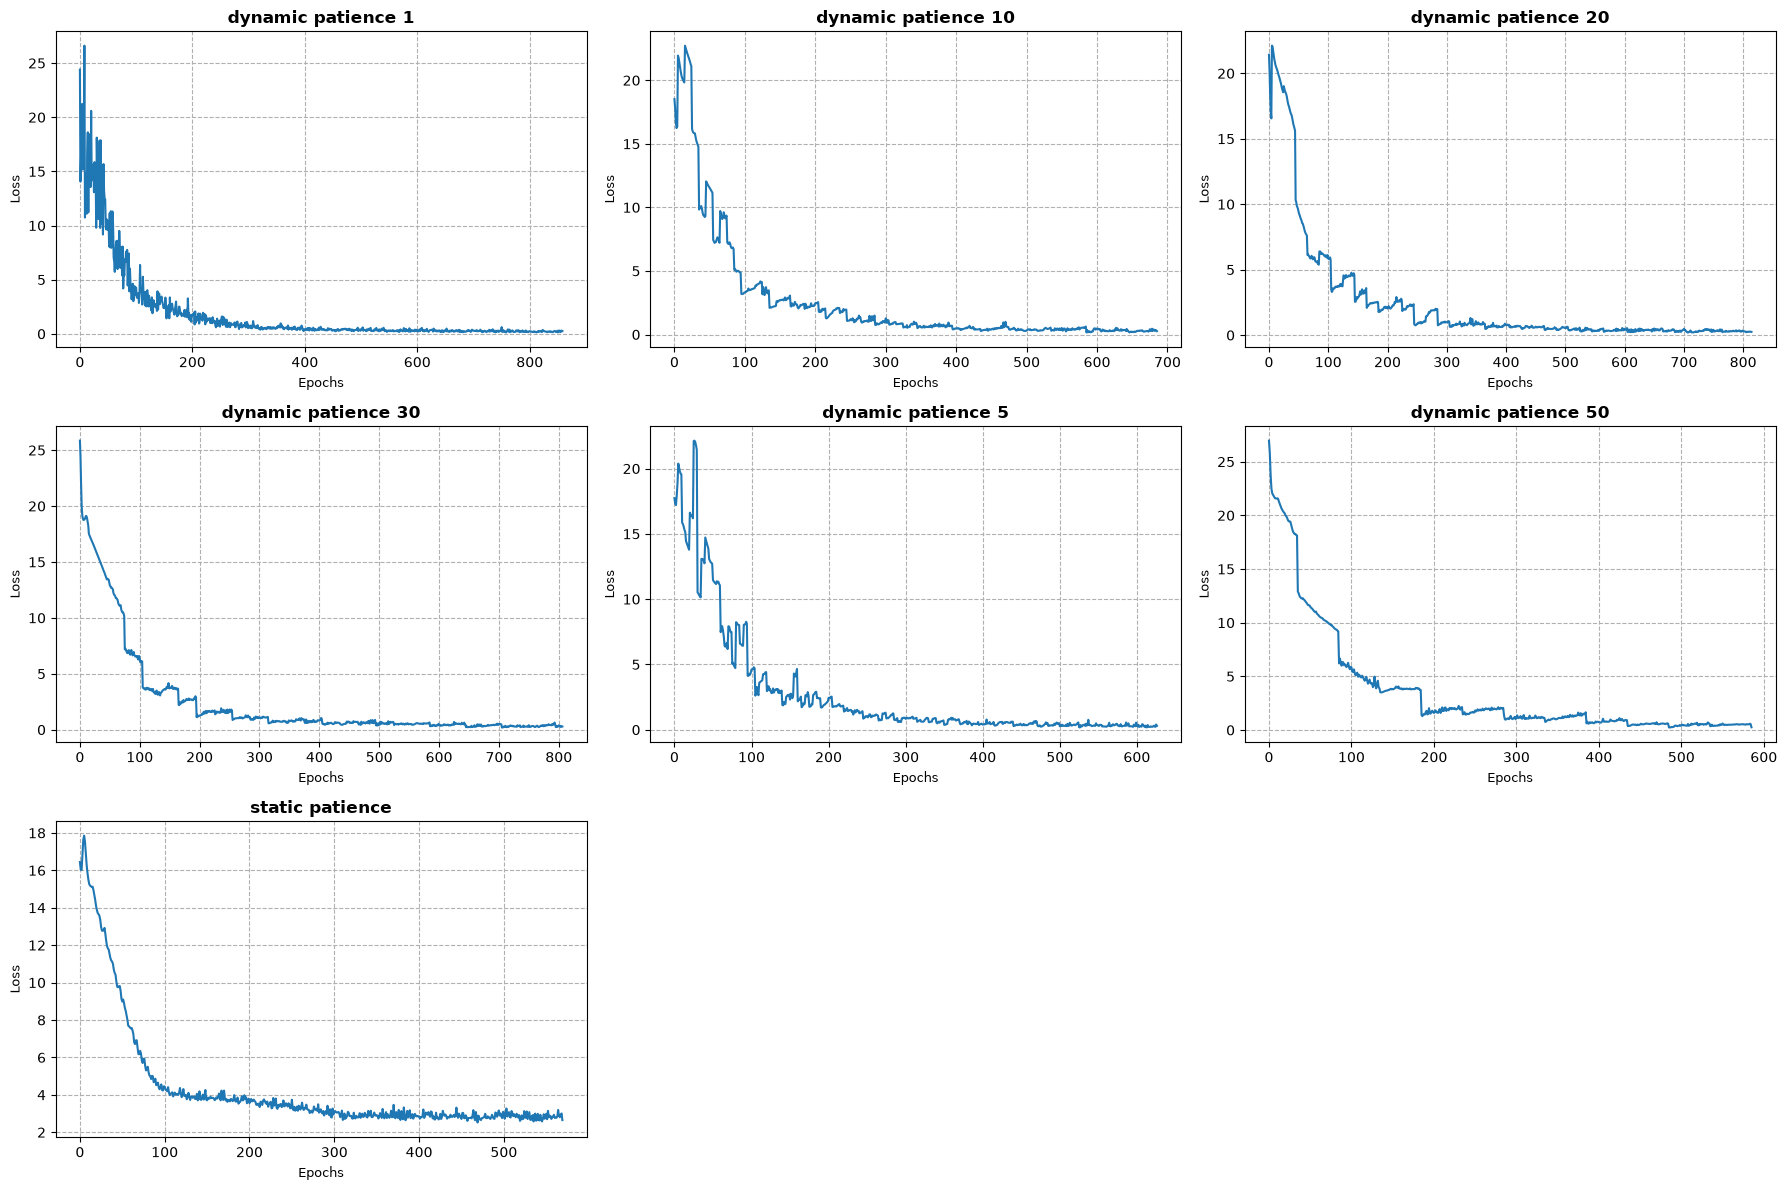

In [ ]:
import matplotlib.pyplot as plt

# seleciona 1 seed para vizualização
seed = seeds[0]

models_reg = sorted(list(set([lh["model"] for lh in loss_hist_reg.values()])))

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()  # Transforma a matriz em uma lista linear para facilitar o loop

for i, model in enumerate(models_reg):
    ax = axes[i]
    
    for key, hist in loss_hist_reg.items():
        if key.endswith(f" s{seed}") and hist["model"] == model:
            # Pega a partir da época 15 pra melhor vizualização pela escala
            loss = hist["val_loss"][15:]
            epochs = range(len(hist["val_loss"]) - 15)
            
            ax.plot(epochs, loss)
            
    ax.set_title(model, fontweight='bold')
    ax.set_xlabel("Epochs", fontsize=9)
    ax.set_ylabel("Loss", fontsize=9)
    ax.grid(True, linestyle="--")


for j in range(len(models_reg), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

- Classificação

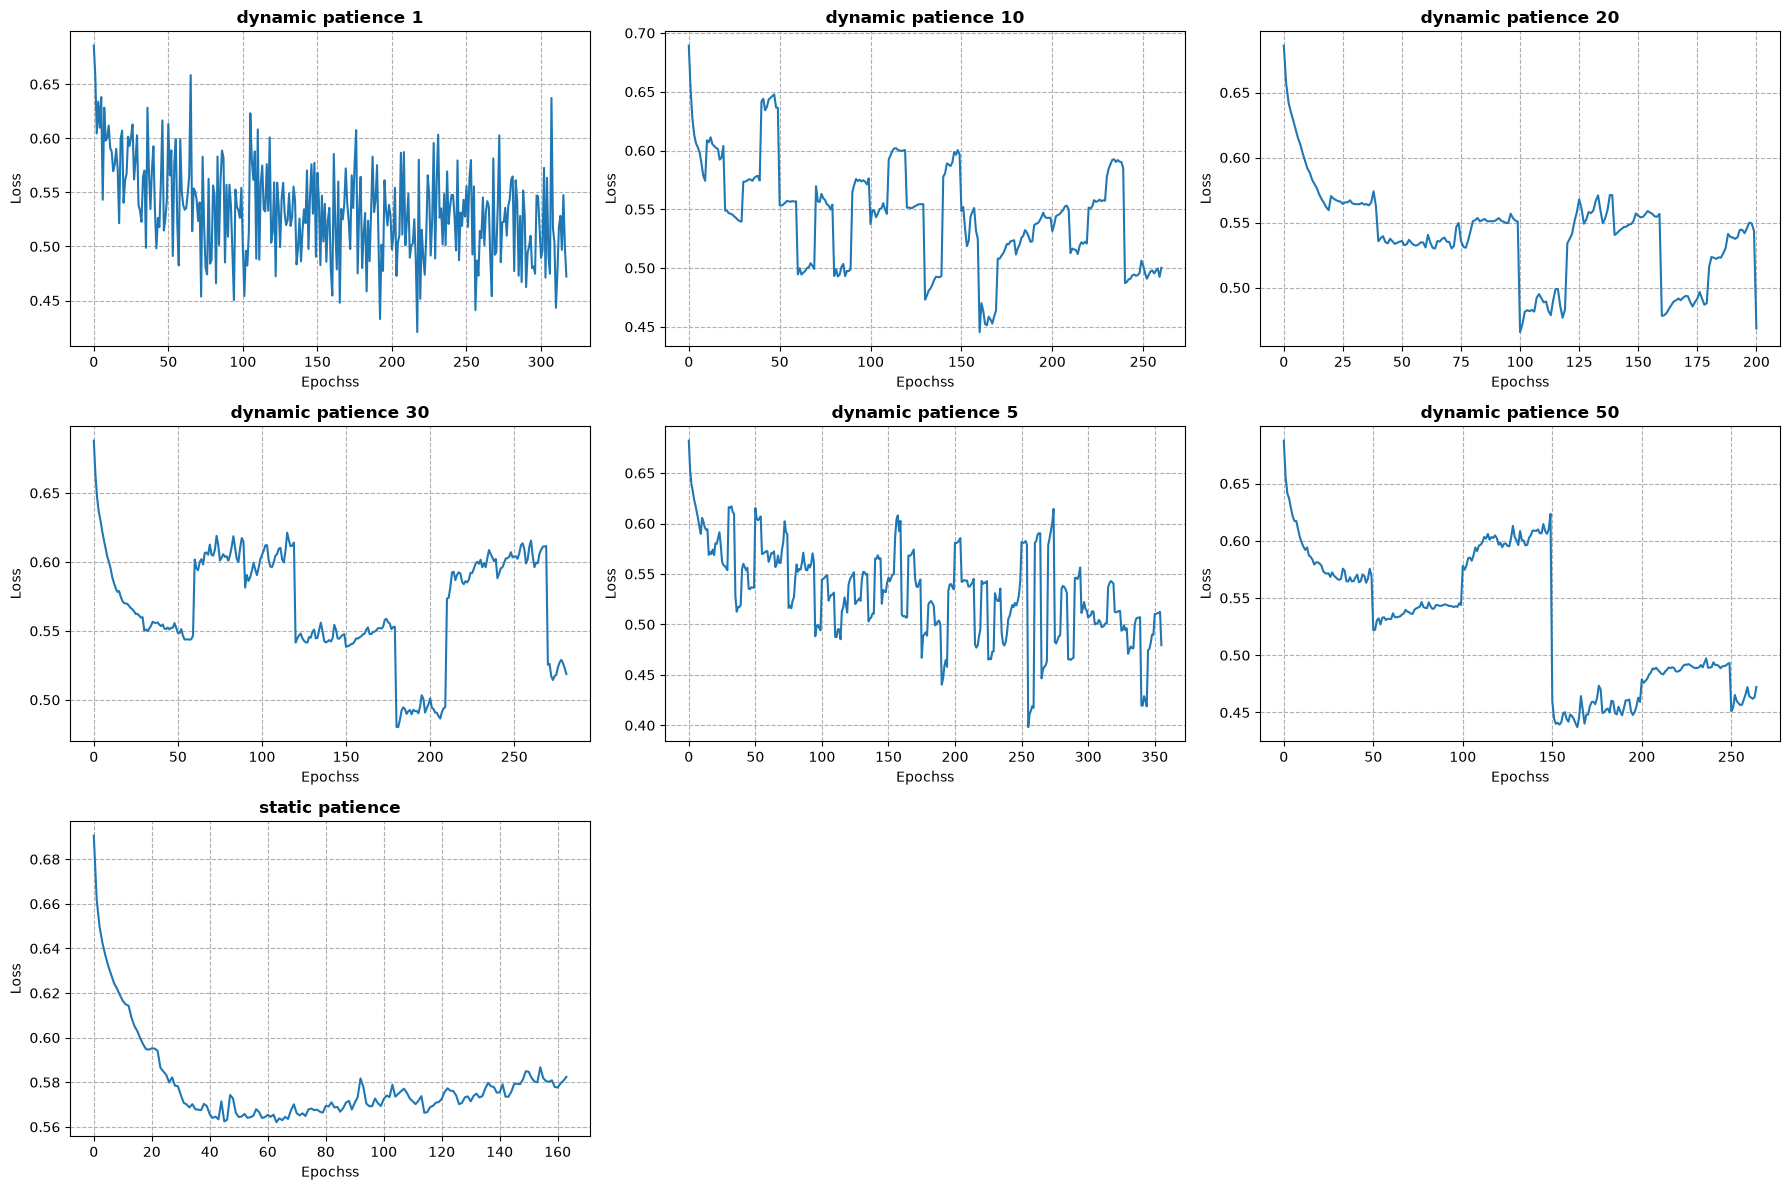

In [ ]:
import matplotlib.pyplot as plt

# seleciona 1 seed para vizualização
seed = seeds[0]

models_cla = sorted(list(set([lh["model"] for lh in loss_hist_cla.values()])))

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()  # Transforma a matriz em uma lista linear para facilitar o loop

for i, nome_modelo in enumerate(models_cla):
    ax = axes[i]
    
    for key, hist in loss_hist_cla.items():
        if key.endswith(f" s{seed}") and hist["model"] == nome_modelo:
            ax.plot(hist["val_loss"])
            
    ax.set_title(nome_modelo, fontweight='bold')
    ax.set_xlabel("Epochss")
    ax.set_ylabel("Loss")
    ax.grid(True, linestyle="--")


for j in range(len(models_cla), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Conclusão